<a href="https://colab.research.google.com/github/yohanagabrielasr-prog/HandsOnMg4/blob/main/HandsOnMg5Matria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# MEMBENTUK TABEL MORTALITA (qx, px, lx, dx)

# Definisikan usia 0–100
ages = np.arange(0, 101)

# Data mortalita fiktif (qx meningkat seiring usia)
qx_data = np.linspace(0.001, 0.5, len(ages)) + (ages / 1500)
qx_data[qx_data > 1] = 1  # batas maksimum probabilitas

# Buat DataFrame
mortality_table = pd.DataFrame({
    'x': ages,
    'qx': qx_data
})

# Hitung px
mortality_table['px'] = 1 - mortality_table['qx']

# Inisialisasi lx
radix = 100_000
mortality_table.loc[0, 'lx'] = radix

# Hitung lx untuk usia selanjutnya
for i in range(1, len(mortality_table)):
    mortality_table.loc[i, 'lx'] = (
        mortality_table.loc[i-1, 'lx'] * mortality_table.loc[i-1, 'px']
    )

# Hitung dx
mortality_table['dx'] = mortality_table['lx'] * mortality_table['qx']

print("Tabel Mortalita Awal (10 baris pertama):")
print(mortality_table.head(10))


# HITUNG Lx, Tx, dan ex (LIFE EXPECTANCY)


# Hitung Lx (asumsi UDD)
mortality_table['Lx'] = mortality_table['lx'] - 0.5 * mortality_table['dx']

# Penyesuaian usia terakhir
last_idx = mortality_table.index[-1]
mortality_table.loc[last_idx, 'Lx'] = (
    mortality_table.loc[last_idx, 'lx'] / mortality_table.loc[last_idx, 'qx']
)

# Pastikan tidak negatif
mortality_table['Lx'] = np.maximum(0, mortality_table['Lx'])

# Hitung Tx
mortality_table['Tx'] = mortality_table['Lx'][::-1].cumsum()[::-1]

# Hitung ex
mortality_table['ex'] = mortality_table['Tx'] / mortality_table['lx']

print("\nTabel Mortalita Lengkap (10 baris pertama):")
print(mortality_table.head(10))

print("\nTabel Mortalita Lengkap (10 baris terakhir):")
print(mortality_table.tail(10))




Tabel Mortalita Awal (10 baris pertama):
   x        qx        px             lx           dx
0  0  0.001000  0.999000  100000.000000   100.000000
1  1  0.006657  0.993343   99900.000000   665.001000
2  2  0.012313  0.987687   99234.999000  1221.913621
3  3  0.017970  0.982030   98013.085379  1761.295144
4  4  0.023627  0.976373   96251.790235  2274.108964
5  5  0.029283  0.970717   93977.681271  2751.979767
6  6  0.034940  0.965060   91225.701504  3187.426011
7  7  0.040597  0.959403   88038.275494  3574.060524
8  8  0.046253  0.953747   84464.214970  3906.751490
9  9  0.051910  0.948090   80557.463480  4181.737929

Tabel Mortalita Lengkap (10 baris pertama):
   x        qx        px             lx           dx            Lx  \
0  0  0.001000  0.999000  100000.000000   100.000000  99950.000000   
1  1  0.006657  0.993343   99900.000000   665.001000  99567.499500   
2  2  0.012313  0.987687   99234.999000  1221.913621  98624.042189   
3  3  0.017970  0.982030   98013.085379  1761.29514

In [ ]:
# SOAL 7A

# Mortalita seleksi
q_50_sel = 0.0010
q_50_sel_1 = 0.0015

p2_50_sel = (1 - q_50_sel) * (1 - q_50_sel_1)

print("\nSoal 7a:")
print("2p_[50] =", p2_50_sel)


# SOAL 7B

q_52 = 0.0025
p_52 = 1 - q_52

print("\nSoal 7b:")
print("p_52 =", p_52)


Soal 7a:
2p_[50] = 0.9975015

Soal 7b:
p_52 = 0.9975


In [ ]:
# NO 8

p40 = 0.998
p41 = 0.9979

# Peluang satu orang hidup 40 → 42
p2_40 = p40 * p41

# Peluang dua orang (independen)
prob_kembar = p2_40 ** 2

print("\nSoal 8:")
print("Peluang dua orang kembar hidup sampai usia 42 =", prob_kembar)


Soal 8:
Peluang dua orang kembar hidup sampai usia 42 = 0.99182517557764


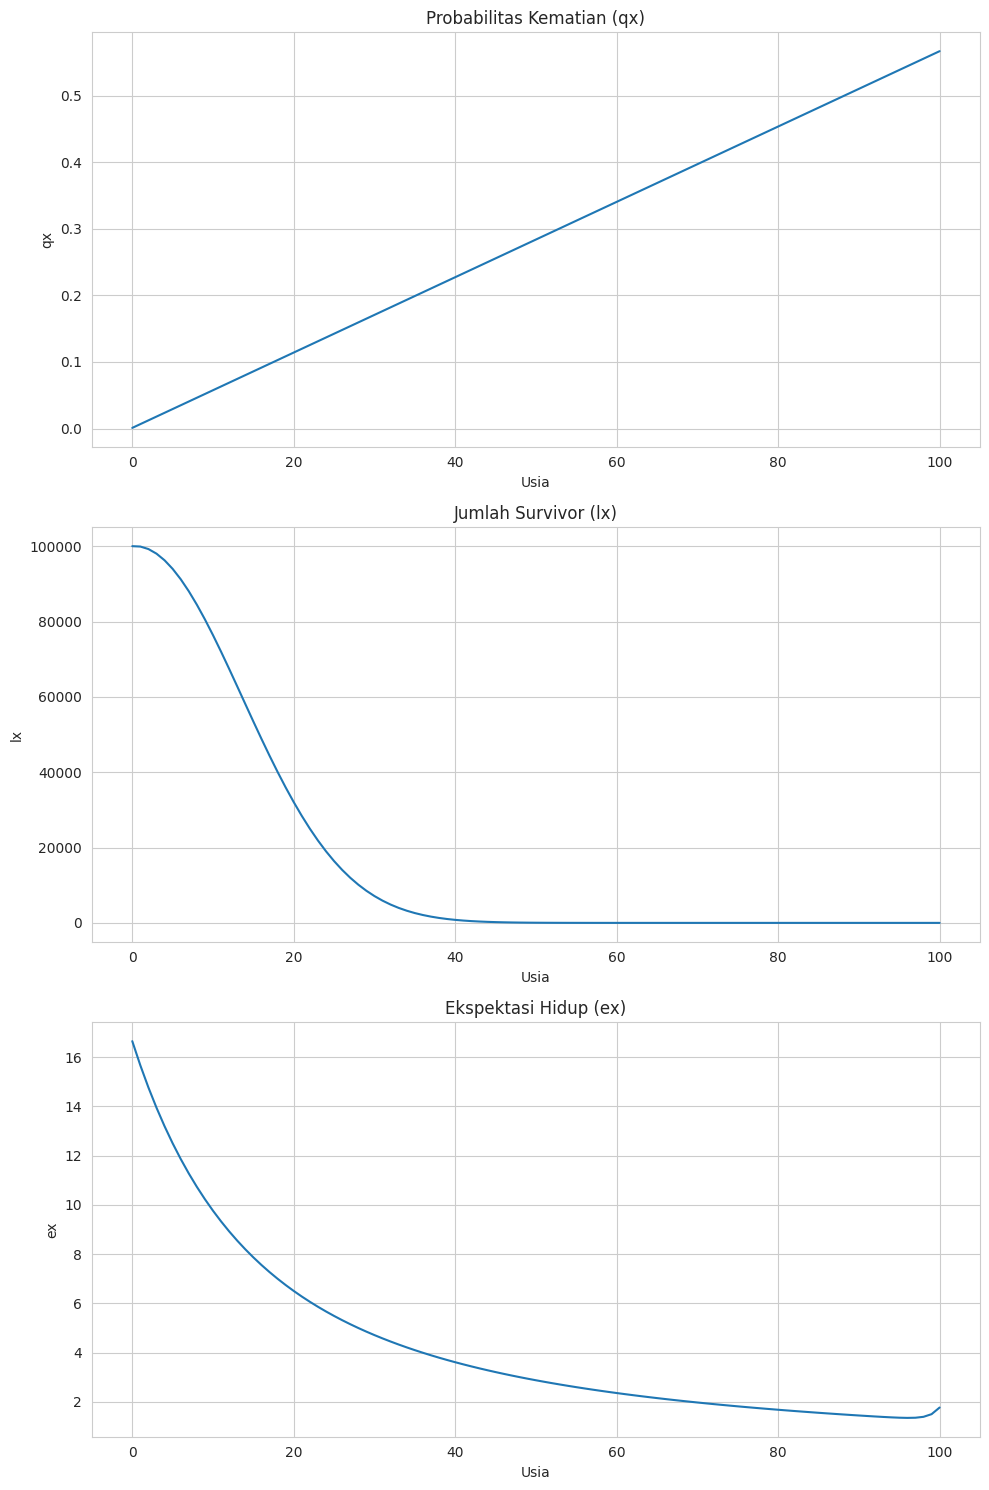

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

# MEMBENTUK TABEL MORTALITA (qx, px, lx, dx)

# Definisikan usia 0–100
ages = np.arange(0, 101)

# Data mortalita (qx meningkat seiring usia)
qx_data = np.linspace(0.001, 0.5, len(ages)) + (ages / 1500)
qx_data[qx_data > 1] = 1  # batas maksimum probabilitas

# Buat DataFrame
mortality_table = pd.DataFrame({
    'x': ages,
    'qx': qx_data
})

# Hitung px
mortality_table['px'] = 1 - mortality_table['qx']

# Inisialisasi lx
radix = 100_000
mortality_table.loc[0, 'lx'] = radix

# Hitung lx untuk usia selanjutnya
for i in range(1, len(mortality_table)):
    mortality_table.loc[i, 'lx'] = (
        mortality_table.loc[i-1, 'lx'] * mortality_table.loc[i-1, 'px']
    )

# Hitung dx
mortality_table['dx'] = mortality_table['lx'] * mortality_table['qx']


# HITUNG Lx, Tx, dan ex (LIFE EXPECTANCY)


# Hitung Lx (asumsi UDD)
mortality_table['Lx'] = mortality_table['lx'] - 0.5 * mortality_table['dx']

# Penyesuaian usia terakhir
last_idx = mortality_table.index[-1]
mortality_table.loc[last_idx, 'Lx'] = (
    mortality_table.loc[last_idx, 'lx'] / mortality_table.loc[last_idx, 'qx']
)

# Pastikan tidak negatif
mortality_table['Lx'] = np.maximum(0, mortality_table['Lx'])

# Hitung Tx
mortality_table['Tx'] = mortality_table['Lx'][::-1].cumsum()[::-1]

# Hitung ex
mortality_table['ex'] = mortality_table['Tx'] / mortality_table['lx']

# VISUALISASI

fig, axes = plt.subplots(3, 1, figsize=(10, 15))

# Grafik qx
sns.lineplot(
    ax=axes[0],
    x='x',
    y='qx',
    data=mortality_table
)
axes[0].set_title('Probabilitas Kematian (qx)')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('qx')

# Grafik lx
sns.lineplot(
    ax=axes[1],
    x='x',
    y='lx',
    data=mortality_table
)
axes[1].set_title('Jumlah Survivor (lx)')
axes[1].set_xlabel('Usia')
axes[1].set_ylabel('lx')

# Grafik ex
sns.lineplot(
    ax=axes[2],
    x='x',
    y='ex',
    data=mortality_table
)
axes[2].set_title('Ekspektasi Hidup (ex)')
axes[2].set_xlabel('Usia')
axes[2].set_ylabel('ex')

plt.tight_layout()
plt.show()